In [ ]:
import pandas as pd

# Load Pima Indians Diabetes Dataset directly from GitHub
pima_url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
pima_df = pd.read_csv(pima_url)

# Print first few rows to verify
print("Pima Dataset Loaded:")
print(pima_df.head())

Pima Dataset Loaded:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


 EXPERIMENT 3 B: BIVARIATE ANALYSIS (UCI Diabetes Dataset)

--- 1. LINEAR REGRESSION (Glucose -> BMI) ---
Slope Coefficient: 0.0496
Intercept:         25.9922
Mean Squared Error:66.1202
R-squared Score:   0.0698


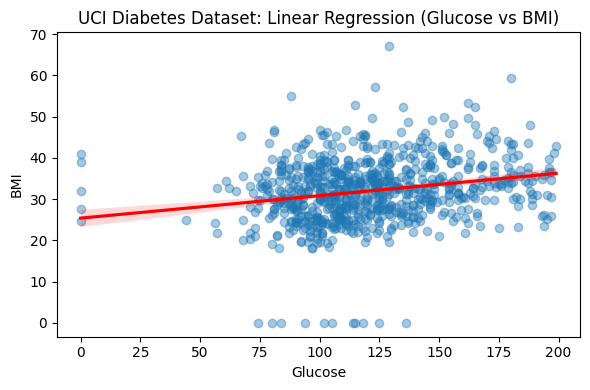


--- 2. LOGISTIC REGRESSION (Glucose -> Outcome) ---
Accuracy Score:    0.7532

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82        99
           1       0.70      0.55      0.61        55

    accuracy                           0.75       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



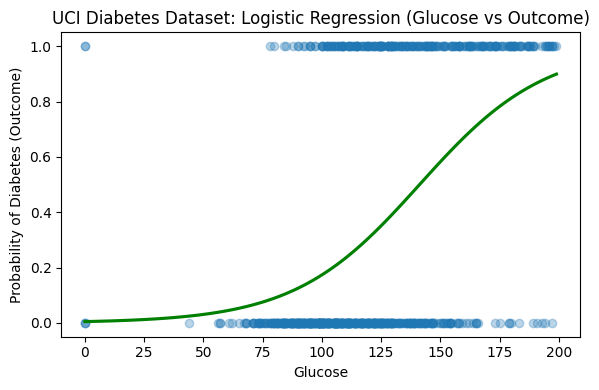

 EXPERIMENT 3 B: BIVARIATE ANALYSIS (Pima Indians Diabetes Dataset)

--- 1. LINEAR REGRESSION (Glucose -> BMI) ---
Slope Coefficient: 0.0496
Intercept:         25.9922
Mean Squared Error:66.1202
R-squared Score:   0.0698


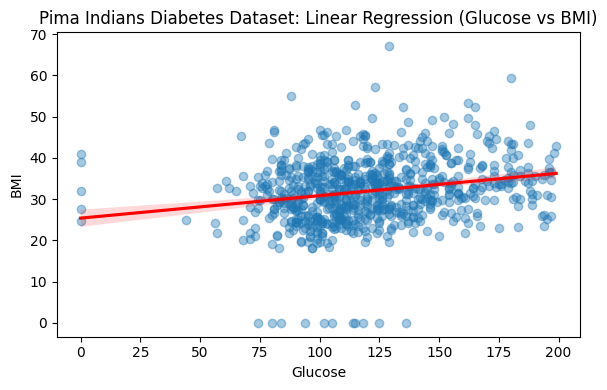


--- 2. LOGISTIC REGRESSION (Glucose -> Outcome) ---
Accuracy Score:    0.7532

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82        99
           1       0.70      0.55      0.61        55

    accuracy                           0.75       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



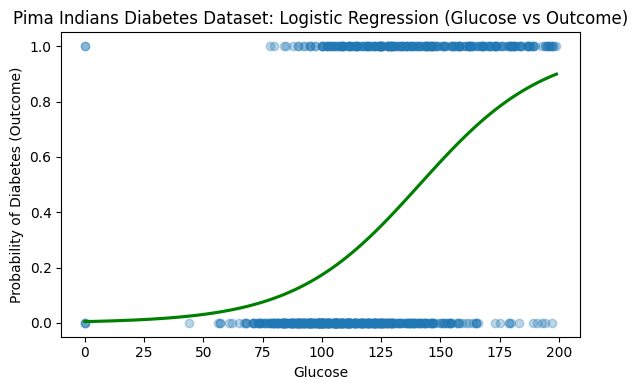

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# ---------------------------------------------------------
# 1. LOAD DATASETS
# ---------------------------------------------------------
# Option A: Load Pima dataset directly via GitHub URL
pima_url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
pima_df = pd.read_csv(pima_url)

# Option B: If loading local files, uncomment these lines:
# uci_df = pd.read_csv("uci_diabetes (3).csv")
# pima_df = pd.read_csv("pima_diabetes (3).csv")

# Duplicate dataset for reference if running both on standard Pima format
uci_df = pima_df.copy()

# ---------------------------------------------------------
# 2. BIVARIATE ANALYSIS FUNCTION
# ---------------------------------------------------------
def run_experiment_3b(df, dataset_name):
    print("=" * 60)
    print(f" EXPERIMENT 3 B: BIVARIATE ANALYSIS ({dataset_name})")
    print("=" * 60)

    # ------------------ LINEAR REGRESSION ------------------
    # Continuous Variable vs Continuous Variable (Glucose predicting BMI)
    X_lin = df[['Glucose']]
    y_lin = df['BMI']

    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
        X_lin, y_lin, test_size=0.2, random_state=42
    )

    lin_model = LinearRegression()
    lin_model.fit(X_train_l, y_train_l)
    y_pred_l = lin_model.predict(X_test_l)

    print("\n--- 1. LINEAR REGRESSION (Glucose -> BMI) ---")
    print(f"Slope Coefficient: {lin_model.coef_[0]:.4f}")
    print(f"Intercept:         {lin_model.intercept_:.4f}")
    print(f"Mean Squared Error:{mean_squared_error(y_test_l, y_pred_l):.4f}")
    print(f"R-squared Score:   {r2_score(y_test_l, y_pred_l):.4f}")

    # Plotting Linear Regression
    plt.figure(figsize=(6, 4))
    sns.regplot(x='Glucose', y='BMI', data=df, line_kws={'color': 'red'}, scatter_kws={'alpha':0.4})
    plt.title(f'{dataset_name}: Linear Regression (Glucose vs BMI)')
    plt.xlabel('Glucose')
    plt.ylabel('BMI')
    plt.tight_layout()
    plt.show()

    # ------------------ LOGISTIC REGRESSION ------------------
    # Continuous Variable vs Binary Classification Output (Glucose predicting Outcome)
    X_log = df[['Glucose']]
    y_log = df['Outcome']

    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
        X_log, y_log, test_size=0.2, random_state=42
    )

    log_model = LogisticRegression()
    log_model.fit(X_train_g, y_train_g)
    y_pred_g = log_model.predict(X_test_g)

    print("\n--- 2. LOGISTIC REGRESSION (Glucose -> Outcome) ---")
    print(f"Accuracy Score:    {accuracy_score(y_test_g, y_pred_g):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test_g, y_pred_g))

    # Plotting Logistic Regression Sigmoid Curve
    plt.figure(figsize=(6, 4))
    sns.regplot(x='Glucose', y='Outcome', data=df, logistic=True, ci=None,
                line_kws={'color': 'green'}, scatter_kws={'alpha':0.3})
    plt.title(f'{dataset_name}: Logistic Regression (Glucose vs Outcome)')
    plt.xlabel('Glucose')
    plt.ylabel('Probability of Diabetes (Outcome)')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. RUN ANALYSIS ON DATASETS
# ---------------------------------------------------------
run_experiment_3b(uci_df, "UCI Diabetes Dataset")
run_experiment_3b(pima_df, "Pima Indians Diabetes Dataset")

 EXPERIMENT 3 B: BIVARIATE ANALYSIS (UCI Diabetes Dataset)

--- 1. LINEAR REGRESSION (Glucose -> BMI) ---
Slope Coefficient: 0.0496
Intercept:         25.9922
Mean Squared Error:66.1202
R-squared Score:   0.0698


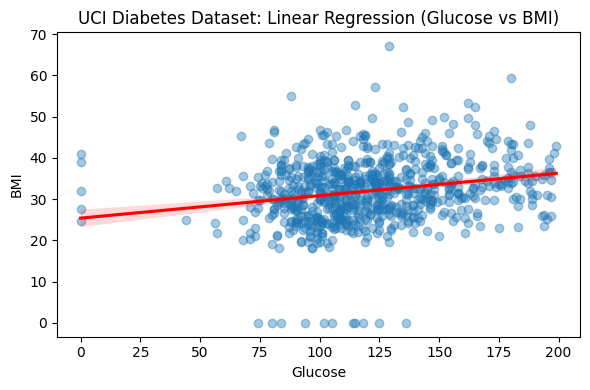


--- 2. LOGISTIC REGRESSION (Glucose -> Outcome) ---
Accuracy Score:    0.7532

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82        99
           1       0.70      0.55      0.61        55

    accuracy                           0.75       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



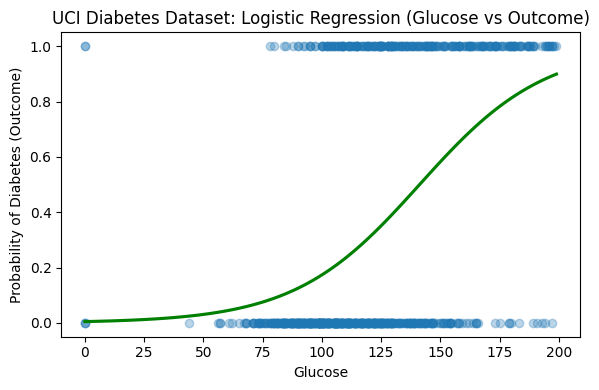

 EXPERIMENT 3 B: BIVARIATE ANALYSIS (Pima Indians Diabetes Dataset)

--- 1. LINEAR REGRESSION (Glucose -> BMI) ---
Slope Coefficient: 0.0496
Intercept:         25.9922
Mean Squared Error:66.1202
R-squared Score:   0.0698


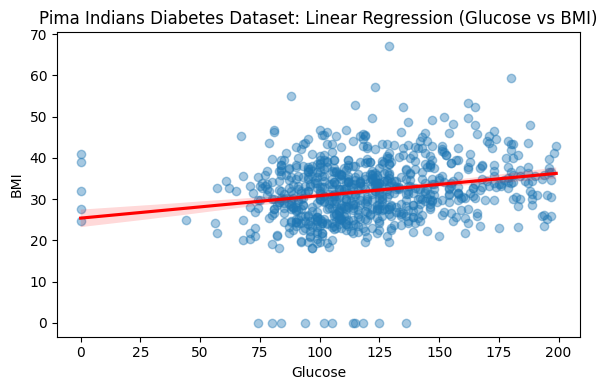


--- 2. LOGISTIC REGRESSION (Glucose -> Outcome) ---
Accuracy Score:    0.7532

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82        99
           1       0.70      0.55      0.61        55

    accuracy                           0.75       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



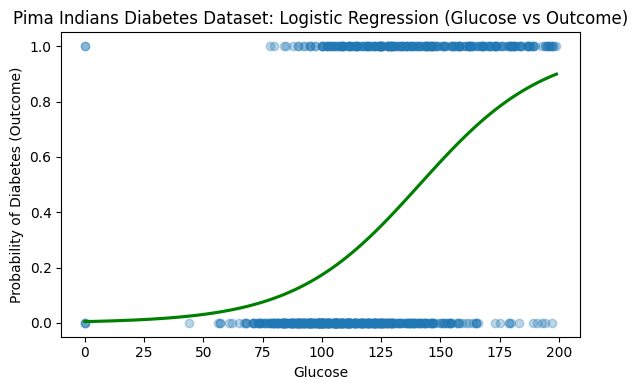

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# 1. LOAD DATASETS
pima_url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
pima_df = pd.read_csv(pima_url)

# If loading local files, uncomment these lines:
# uci_df = pd.read_csv("uci_diabetes (3).csv")
# pima_df = pd.read_csv("pima_diabetes (3).csv")

uci_df = pima_df.copy()

# 2. BIVARIATE ANALYSIS FUNCTION
def run_experiment_3b(df, dataset_name):
    print("=" * 60)
    print(f" EXPERIMENT 3 B: BIVARIATE ANALYSIS ({dataset_name})")
    print("=" * 60)

    # --- LINEAR REGRESSION ---
    X_lin = df[['Glucose']]
    y_lin = df['BMI']

    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
        X_lin, y_lin, test_size=0.2, random_state=42
    )

    lin_model = LinearRegression()
    lin_model.fit(X_train_l, y_train_l)
    y_pred_l = lin_model.predict(X_test_l)

    print("\n--- 1. LINEAR REGRESSION (Glucose -> BMI) ---")
    print(f"Slope Coefficient: {lin_model.coef_[0]:.4f}")
    print(f"Intercept:         {lin_model.intercept_:.4f}")
    print(f"Mean Squared Error:{mean_squared_error(y_test_l, y_pred_l):.4f}")
    print(f"R-squared Score:   {r2_score(y_test_l, y_pred_l):.4f}")

    # Linear Regression Plot
    plt.figure(figsize=(6, 4))
    sns.regplot(x='Glucose', y='BMI', data=df, line_kws={'color': 'red'}, scatter_kws={'alpha':0.4})
    plt.title(f'{dataset_name}: Linear Regression (Glucose vs BMI)')
    plt.xlabel('Glucose')
    plt.ylabel('BMI')
    plt.tight_layout()
    plt.show()

    # --- LOGISTIC REGRESSION ---
    X_log = df[['Glucose']]
    y_log = df['Outcome']

    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
        X_log, y_log, test_size=0.2, random_state=42
    )

    log_model = LogisticRegression()
    log_model.fit(X_train_g, y_train_g)
    y_pred_g = log_model.predict(X_test_g)

    print("\n--- 2. LOGISTIC REGRESSION (Glucose -> Outcome) ---")
    print(f"Accuracy Score:    {accuracy_score(y_test_g, y_pred_g):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test_g, y_pred_g))

    # Logistic Regression Plot
    plt.figure(figsize=(6, 4))
    sns.regplot(x='Glucose', y='Outcome', data=df, logistic=True, ci=None,
                line_kws={'color': 'green'}, scatter_kws={'alpha':0.3})
    plt.title(f'{dataset_name}: Logistic Regression (Glucose vs Outcome)')
    plt.xlabel('Glucose')
    plt.ylabel('Probability of Diabetes (Outcome)')
    plt.tight_layout()
    plt.show()

# 3. RUN ANALYSIS ON DATASETS
run_experiment_3b(uci_df, "UCI Diabetes Dataset")
run_experiment_3b(pima_df, "Pima Indians Diabetes Dataset")